<a href="https://colab.research.google.com/github/UoA-eResearch/atoll-vegetation-health/blob/main/Atoll_vegetation_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atoll Vegetation Health
- script to return repository of vegetation health for Atolls at the Island scale.

## Step-0 install and import modules


In [3]:
!pip install -i https://test.pypi.org/simple/ geeutil # install geeutil functions from test.pypi
from geeutil import featureutils
from geeutil import imageutils
from geeutil import ndutils
from geeutil import imagecollectionutils
from geeutil import hlsutils

import geopandas as gpd
import pandas as pd
import time

import tqdm
from tqdm.contrib.concurrent import process_map
from functools import partial
import glob
import os
from datetime import datetime as dt
from google.colab import userdata

import ee # import earthengine api and init
try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize(project=userdata.get('ee_project')) # need to specify ee project

Looking in indexes: https://test.pypi.org/simple/


## Step-1 Functions

In [9]:
def return_mean_ndvi(geometry): # function to return mean ndvi for geometry
    """
    Calculate mean ndvi for region defined by geometry for all images in ee.ImageCollection with map fuction.

    Args
    geometry - ee.Geometry object representing area
    """
    def get_stats(image):

        indices = image.select(['ndvi'])
        stats = indices.reduceRegion(**{
            'geometry': geometry,
            'reducer': ee.Reducer.mean()
        })
        ndvi = stats.get('ndvi')

        feature = ee.Feature(None, {
            # add indices
            'ndvi': ndvi
        }).copyProperties(image, ['system:time_start', 'region_cloudy_percent', 'area', 'region_pixel_count']) # get properties from image.
        return feature
    return(get_stats)

def return_area(geometry):
  """
  function to return the count of pixels in an image within a geometry
  image - ee.Image object
  """
  def calc_area(image):
      area = ee.Image.pixelArea().reduceRegion(
      reducer=ee.Reducer.sum(),
      geometry=geometry,
      maxPixels=1e10,
      scale=30)
      return image.set('area', area.get('area'))
  return(calc_area)


def return_area_per_pixel(geometry):
  """
  function to return the count of pixels within an area of interest and calculate the area per pixel
  Args
  image - ee.Image object
  geometry - ee.FeatureCollection object representing the area of interest
  """
  def calc_area_per_pixel(image):
      count = image.reduceRegion(
      reducer=ee.Reducer.count(),
      geometry=geometry,
      maxPixels=1e10,
      scale=30)
      return image.set('area_per_pixel', ee.Number(image.get('area')).divide(count.get(image.bandNames().get(0))))
  return(calc_area_per_pixel)


def calc_cloud_pixel_count(geometry):

    def map_pixel_count(image):
      cloud = image.updateMask(image.select('clouds'))
      # return pixel count for area
      pixel_count = cloud.reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=geometry,
            maxPixels=1e10)
      return image.set('mask_pixel_count', pixel_count.get(image.bandNames().get(0))) # select first band in the image.
    return(map_pixel_count)


def calc_pixel_count(geometry):

    def map_pixel_count(image):
      # return pixel count for area
      pixel_count = image.reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=geometry,
            maxPixels=1e10)
      return image.set('region_pixel_count', pixel_count.get(image.bandNames().get(0))) # select one the bands in image
    return(map_pixel_count)


def process_images(feature, sensors, start_date, end_date, folder_path): # process all images in imageCollection
    """
    return mean ndvi for all images an a series of imageCollections,
    returning csv of ndvi timeseries

    Args
    feature - geometry of area for which ndvi is being calculated
    sensor - list of sensor IDs
    folder_path - output directory path
    """
    fn = f"{folder_path}/{feature['properties']['Id']}-timeseries.csv" # define path for timeseries
    aoi = featureutils.item_to_featureCollection(feature) # return cell as ee.featureCollection
    timeseries = []
    if os.path.exists(fn): # check if file exists and return last date if so
      existing_df = pd.read_csv(fn)
      last_date = pd.to_datetime(existing_df['date']).max()
      start_date = last_date.strftime('%Y-%m-%d') # Assuming 'date' is in datetime format

    for i in sensors:
      collection = imagecollectionutils.gen_imageCollection(start_date, end_date, aoi, i)
      images = (collection.map(imageutils.clip_images_to_region(aoi)) # preprocess image collection
                          .map(calc_pixel_count(aoi))
                          .filter(ee.Filter.gt('region_pixel_count', 0))
                          .map(calc_cloud_pixel_count(aoi))
                          .map(imageutils.add_cell_level_cloud_cover_property)
                          .map(return_area(aoi)))
      if images.size().getInfo() != 0:
        print(f"number of images: {images.size().getInfo()}")
        images = (images.map(ndutils.apply_ndvi)) # calc ndvi
        veg_stats = images.map(return_mean_ndvi(aoi)) # return stats
        features = [i for i in veg_stats.getInfo().get('features')]
        for f in features:
          try:
            image_attributes = {}
            date = dt.fromtimestamp(f['properties']['system:time_start'] / 1000.)

            image_attributes['date'] = date # return attributes for each image
            image_attributes['sensor'] = i
            image_attributes['image_id'] = f['id']
            image_attributes['ndvi'] = f['properties']['ndvi']
            image_attributes['region_cloudy_percent'] = f['properties']['region_cloudy_percent']
            image_attributes['valid_pixel_count'] = f['properties']['region_pixel_count']
            image_attributes['area'] = f['properties']['area']

            timeseries.append(image_attributes)
          except:
              print(f"Issue with image id: {f['id']}")


    df = pd.DataFrame.from_dict(timeseries, orient='columns')
    df['ndvi'] = df['ndvi'].round(decimals=3)
    df['area'] = df['area'].astype(int)
    df['region_cloudy_percent'] = df['region_cloudy_percent'].round(decimals=2)
    df['area_per_pixel'] = df['area']/df['valid_pixel_count'] # calc area per pixel
    df['area_per_pixel'] = df['area_per_pixel'].astype(int)

    if os.path.exists(fn):
      df = pd.concat([existing_df, df], ignore_index=True) # concat existing dataframe and orginal is

    df.to_csv(fn)

def preprocess_shapefile(shapefile, buffer_val, island_area):
  """
  function to preprocess atoll shapefile
  Args
  shapefile - polygon representing atoll
  buffer_val - distance to buffer polygons negative values to remove edge pixels
  island_area - area of islands to include in analysis (metres squared)
  """
  gdf = gpd.read_file(shapefile) # input shapefile
  gdf["buffer_geometry"] = gdf.buffer(buffer_val) # buffer polygons
  gdf.set_geometry("buffer_geometry", inplace=True)
  gdf["buffer_area"] = gdf.area
  gdf = gdf[gdf['buffer_area'] >= island_area]
  gdf.to_crs(4326, inplace=True)
  return gdf


## Step 1 - mount google drive
- mount google drive and define repositories
- Root = `/content/drive/MyDrive`



In [5]:
from google.colab import drive

drive.mount('/content/drive') # mount drive

root = "/content/drive/MyDrive" # define root

input_directory_path = f"{root}/Lae" # define path to input shapefiles

output_directory_path = f"{root}/atoll-vegetation-health" # define output directory
if not os.path.exists(output_directory_path):
  os.mkdir(output_directory_path)

Mounted at /content/drive


## Step 2 - Processing
This step will return NDVI timeseries for each island in Atoll where the island is > 1 ha from the harmonised Landsat/Sentinel-2 image collections in GEE, applying following steps:
  1. Returning a geopandas dataframe of islands within the Atoll > 1 ha with a negative buffer 30m applied to each geometry to remove potential mixed pixels.
  2. Defining a directory which is named after the Atoll.
  3. Returning the timeseries for each island, stored as a .csv file as `{island-Id}-timseries.csv`
  4. Return a Geojson of the islands in the same directory.

### Updating the record
The function `process_images()` will check to see if a timeseries already exists for each Atoll/Island if the repository already exists. If so, `start_date` will be defined as the most recent image in the timeseries.

In [10]:
atoll_gdf = preprocess_shapefile(f"{input_directory_path}/Lae_poly.shp", buffer_val=-30, island_area=10000) # minus buffer to remove mixed pixels and remove islands less than 1ha


atoll_name = atoll_gdf.Atoll.unique()[0] # return atoll name
atoll_output_path = os.path.join(output_directory_path, atoll_name) # define directory for Atoll

if not os.path.exists(atoll_output_path):
  os.mkdir(atoll_output_path)

islands = atoll_gdf.iterfeatures() # generate iterable of island geometries

for i in tqdm.tqdm(islands):
  process_images(i, sensors=["HLSL30", "HLSS30"], start_date="2013-01-01", end_date="2025-02-11", folder_path=atoll_output_path)

# return geojson for atoll
geojson_path = f"{atoll_output_path}/atoll.geojson"
if not os.path.exists(geojson_path):
  atoll_gdf.drop(columns=['buffer_geometry', 'buffer_area'], inplace=True)
  atoll_gdf.to_file(f"{atoll_output_path}/atoll.geojson", driver='GeoJSON')

0it [00:00, ?it/s]

number of images: 1


1it [00:01,  1.85s/it]

number of images: 4


2it [00:04,  2.58s/it]

...

8it [00:15,  1.67s/it]

number of images: 4


9it [00:16,  1.55s/it]

number of images: 7


10it [00:18,  1.83s/it]


## Examine images
Scripts in this section can be used to view individual images for an Atoll under investigation. The image and the Atoll will be displayed in the map view.
  - Image is stored in the `image` variable in `line 6`
  - atoll shapfile is stored in `line 8`

In [ ]:
## FUNCTIONS ##
def return_featureCollection(gdf):
  features = []
  for i in atoll_gdf.iterfeatures():
    aoi = featureutils.item_to_featureCollection(i) # return cell as ee.featureCollection
    features.append(aoi)

  merged_collection = ee.FeatureCollection([])
  for i in features:
    merged_collection = merged_collection.merge(i)
  return merged_collection


In [ ]:
import geemap.core as geemap

map = geemap.Map()

# Load an image.
image = ee.Image("NASA/HLS/HLSS30/v002/T58PFQ_20240102T233251")

atoll_gdf = preprocess_shapefile(f"{input_directory_path}/Lae_poly.shp", buffer_val=-30, island_area=10000) # return ee.featureCollection for atoll

atoll_ee = return_featureCollection(atoll_gdf)

map.centerObject(atoll_ee, zoom=12)

# Define the visualization parameters.
image_viz_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min':0.01,
    'max':0.18,
}

# Add the image layer to the map and display it.
map.add_layer(image, image_viz_params, 'image')
map.add_layer(atoll_ee, {}, 'atoll')


display(map)

Map(center=[8.931876222981376, 166.2556415947974], controls=(ZoomControl(options=['position', 'zoom_in_text', …

## Plot timeseries
scripts to plot NDVI timeseries for each island in an Atoll.
  1. Set `output_directory_path`
  2. Set `atoll_name`
  3. Remove observations containing cloud using `line 17`.



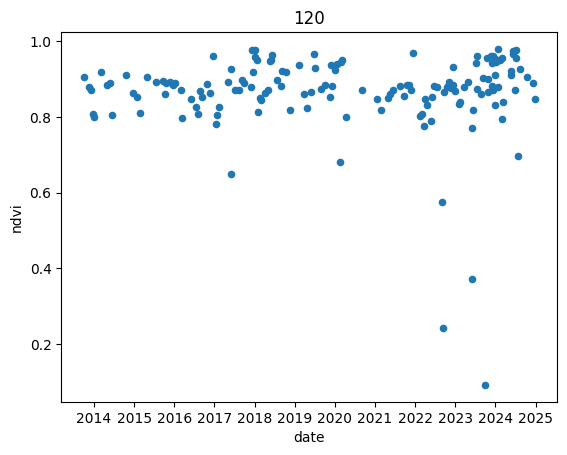

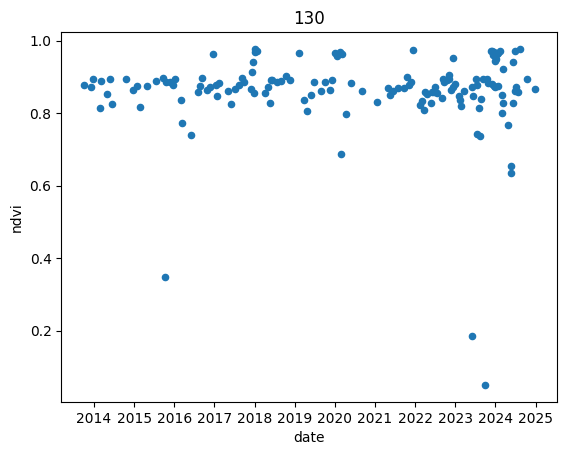

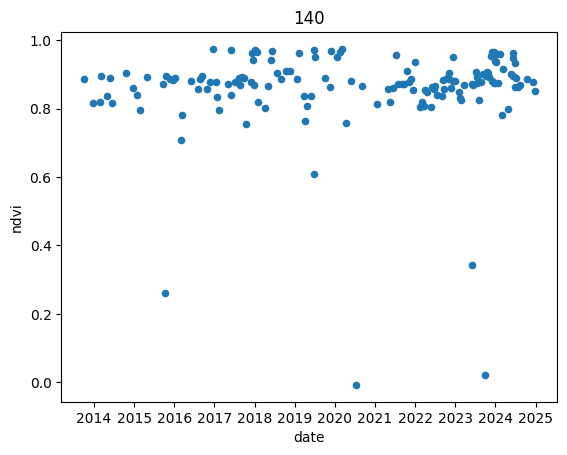

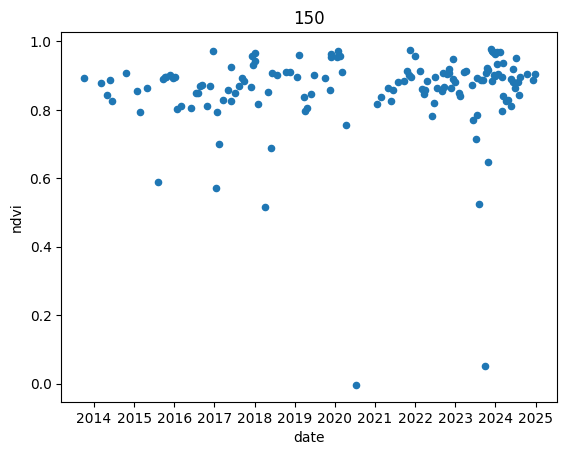

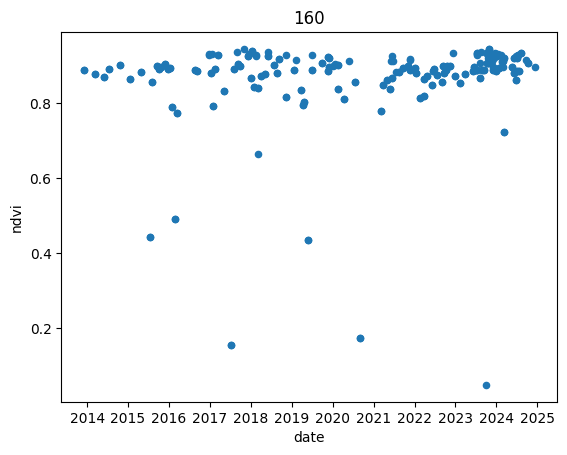

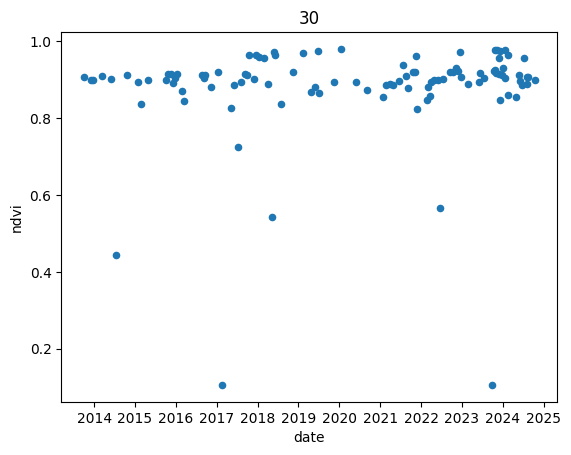

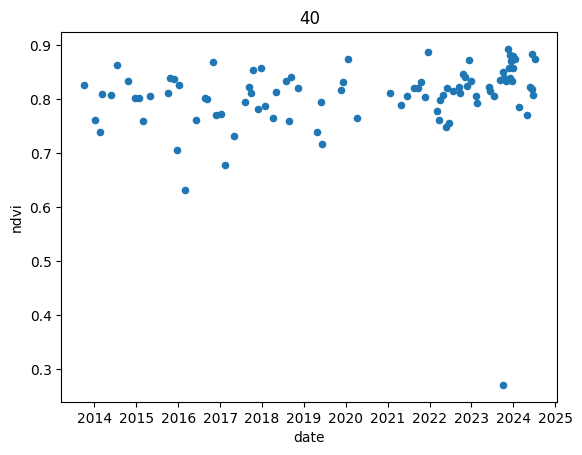

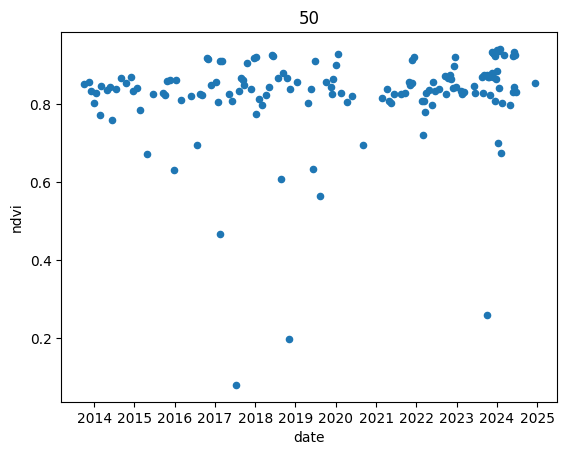

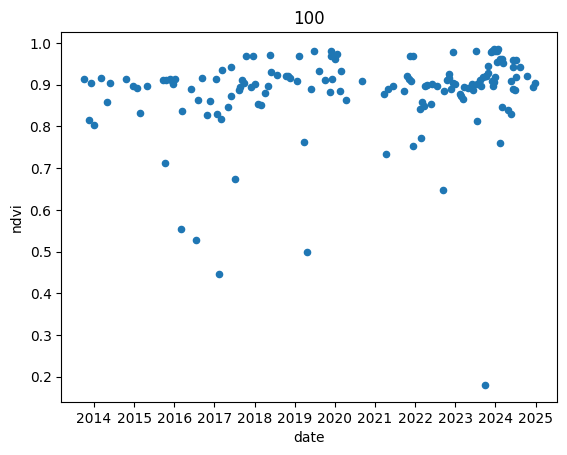

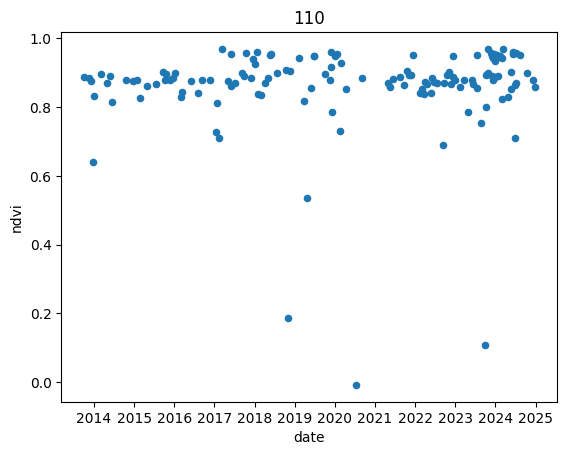

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


output_directory_path = f"{root}/atoll-vegetation-health"
atoll_name = 'Lae'

atoll_fp = f'{output_directory_path}/{atoll_name}'

files = glob.glob(f'{atoll_fp}/*.csv')


for f in files:
  id = f.split('/')[-1].split('-')[0]
  df = pd.read_csv(f)
  df['date'] = pd.to_datetime(df['date'])
  df = df[df['region_cloudy_percent'] == 0]
  #df = df[df['area_per_pixel'] <= 950]
  fig, ax = plt.subplots()  # Create a figure and axes object

  df.plot(x='date', y='ndvi', title=id, kind='scatter', ax=ax)  # Plot on the axes

  # Format the x-axis to show only years
  years = mdates.YearLocator()   # every year
  years_fmt = mdates.DateFormatter('%Y')

  ax.xaxis.set_major_locator(years)
  ax.xaxis.set_major_formatter(years_fmt)

  plt.show()


## Interactive map
Use this section to view timeseries in interactive map view.

1. set `output_directory_path`, `atoll_name`, `atoll_output_path`.


In [68]:
!pip install folium
import folium
import json
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import io
import base64

In [69]:
output_directory_path = f"{root}/atoll-vegetation-health"
atoll_name = 'Lae'
atoll_output_path = f"{output_directory_path}/{atoll_name}"

# Load GeoJSON data
gdf = gpd.read_file(f"{atoll_output_path}/atoll.geojson")

gdf.to_crs(4326, inplace=True)
gdf['coords'] = gdf['geometry'].apply(lambda geom: geom.centroid.coords[0])

coords = (gdf['coords'].iloc[0][-1], gdf['coords'].iloc[0][0])

# Load CSV files for each polygon and store them in a dictionary
csv_data = {}
for file in glob.glob(f'{atoll_output_path}/*.csv'):
    polygon_id = os.path.basename(file).split('-')[0]
    csv_data[polygon_id] = pd.read_csv(file)


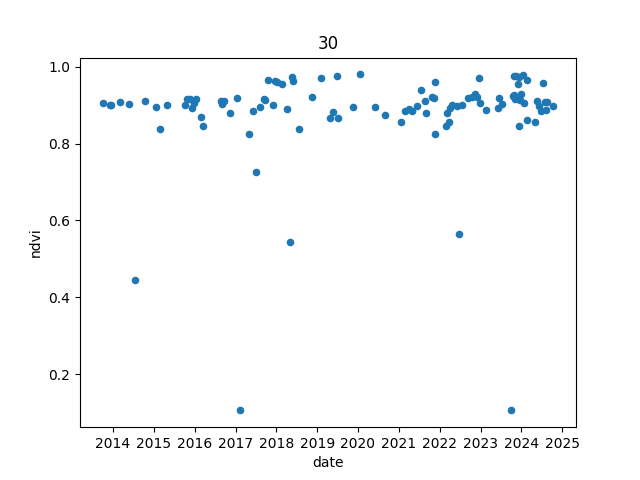
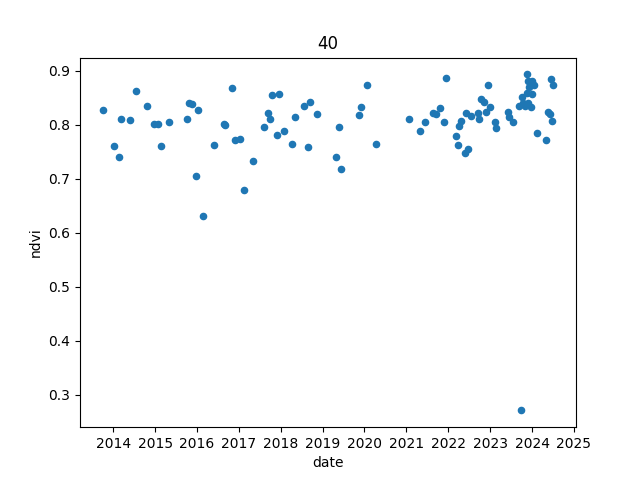
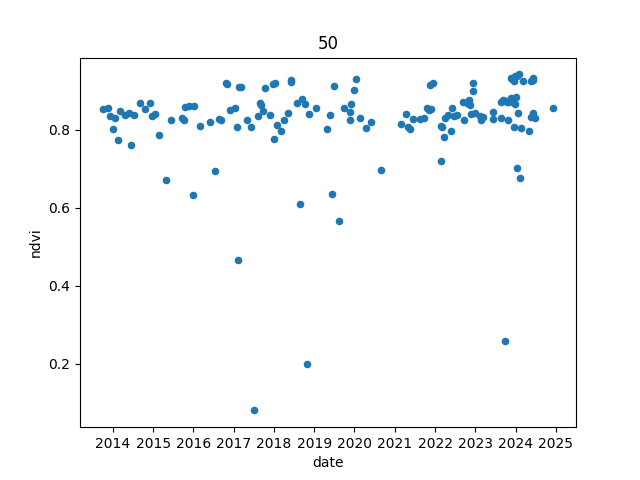
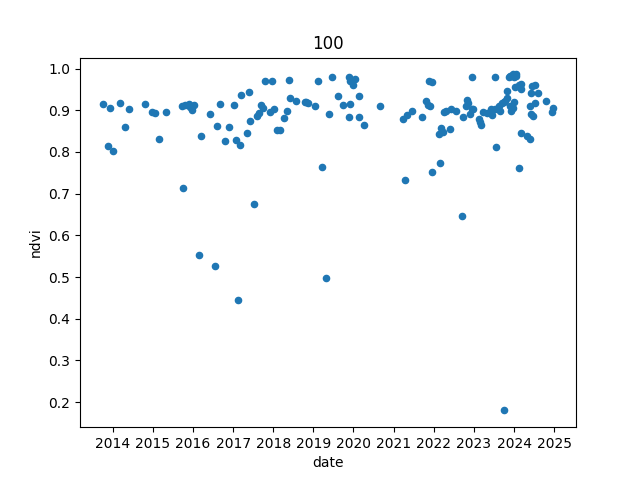
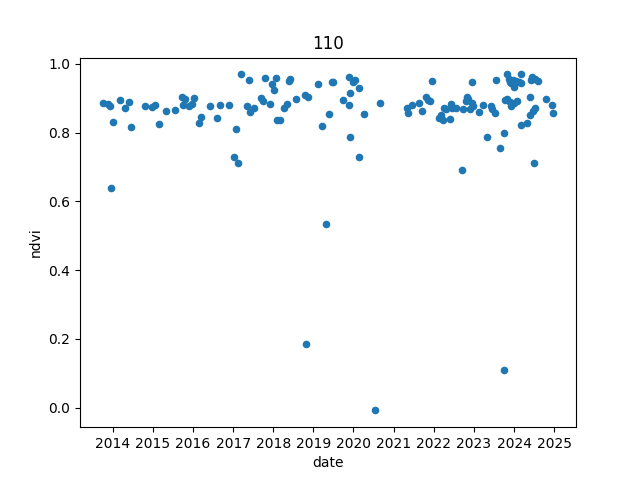
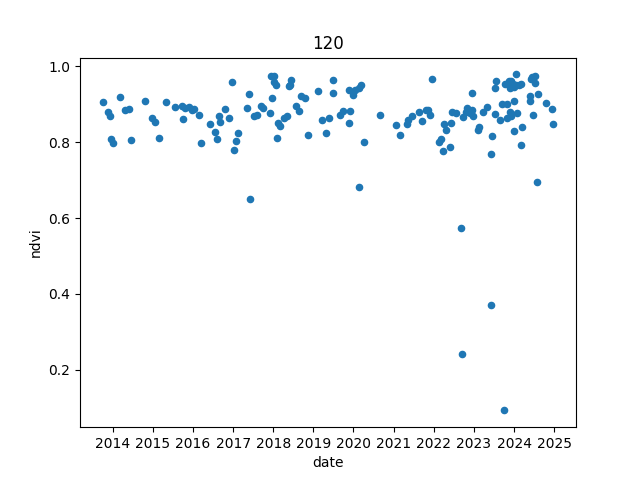
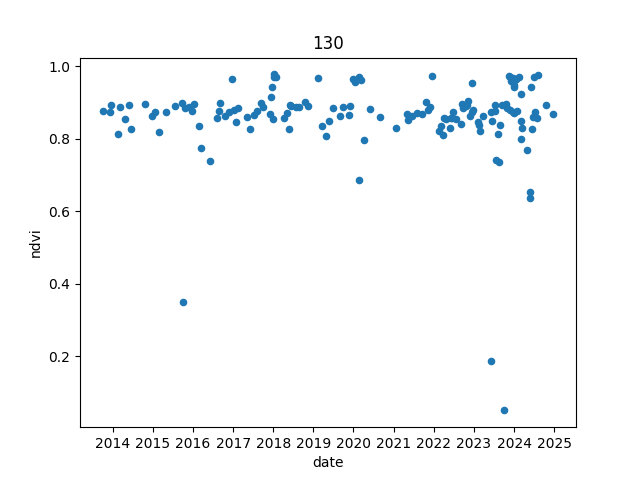
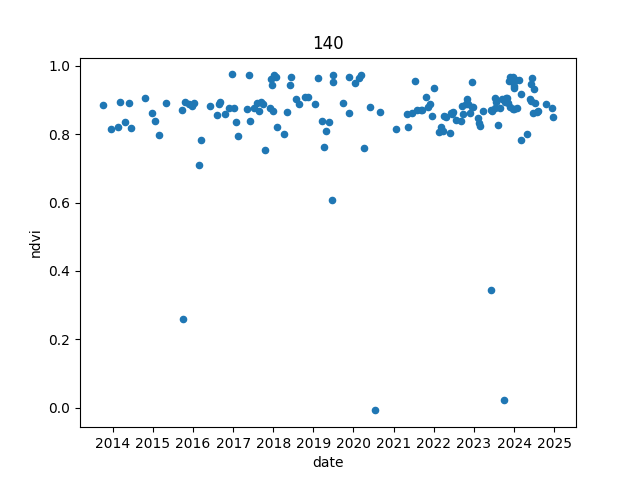
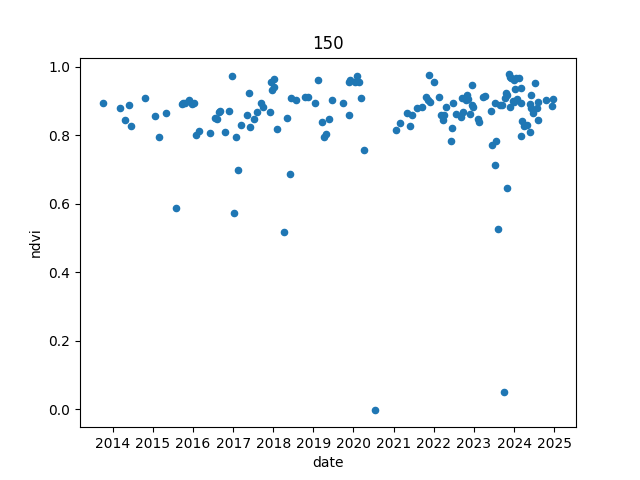
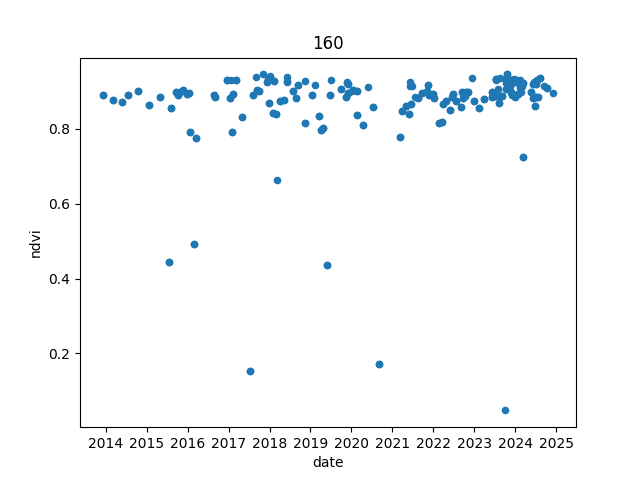

In [77]:
# Create a base map centered on the atoll
m = folium.Map(coords,zoom_start=12)

# Function to generate and embed time series plot
def generate_plot_html(polygon_id):
    polygon_id = str(polygon_id)
    if polygon_id in csv_data:
        df = csv_data[polygon_id]
        df['date'] = pd.to_datetime(df['date'])
        df = df[df['region_cloudy_percent'] == 0] # remove observations including cloud

        fig, ax = plt.subplots()
        df.plot(x='date', y='ndvi', title=f"Island ID: {polygon_id}", kind='scatter', ax=ax)
        years = mdates.YearLocator()
        years_fmt = mdates.DateFormatter('%Y')
        ax.xaxis.set_major_locator(years)
        ax.xaxis.set_major_formatter(years_fmt)

        # Save plot to a temporary buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        data = base64.b64encode(buf.read()).decode('utf-8')
        plt.close()  # Close the plot to release resources

        # Create HTML for embedded plot
        plot_html = f'<img src="data:image/png;base64,{data}">'
        return plot_html
    else:
        return "No data available for this polygon."

# Add GeoJSON layer to the map with click event handler
for _, row in gdf.iterrows():
    polygon_id = row['Id']
    plot_html = generate_plot_html(polygon_id)
    popup = folium.Popup(plot_html, max_width=750)
    folium.Marker(location=[row['coords'][1], row['coords'][0]], popup=popup, tooltip=polygon_id).add_to(m)

m # display map.